In [1]:
# Swap in an Ornstein–Uhlenbeck (OU / exponential) kernel and re-run the demo
# k(x, x') = variance * exp(-|x - x'| / length_scale)
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact
import seaborn as sns

## Model of a time-dependent Ornstein-Uhlenbeck process

$\theta$: task variable   
$s_t(\theta) \in \mathbf{R^{K \times T}}$: Input features mapping to $\theta$.   
$U^\top \in \mathbf{R^{N\times K}}$: The OU drifting term.   
$\mathbf{X \in R^{N \times T}}$: the input neurons' activities. The $\mathbf{X = U^\top s(\theta)}$   
$N$: number of input neurons    
$K$: number of tuning functions toward $\theta$.   
$T$: number of samples in $X$.    
$d$: OU random walk step.    
$\xi \sim \mathcal{N}(0,I)$: white noise. 
$\alpha$: OU drift strength.

Workflow:
1. Define variable $\theta$, draw samples from Von Mises distribution.
2. Construct a Gaussian process to get $s(\theta)$.
3. Define the OU process, make the drift on $U$.
4. Simulate $X$. 

### functions

In [2]:
# ---------------------- Core utils ----------------------
TAU = 2 * np.pi

def wrap_angle(theta):
    return (theta % TAU)

def theta_grid(n_bins=256):
    return np.linspace(0.0, TAU, n_bins, endpoint=False)

# Periodic RBF kernel on the circle, the kernel function
# k(θ,θ') = σ² * exp( - 2 sin²((θ-θ')/2) / ℓ² )
def periodic_rbf_kernel(theta1, theta2, length_scale=0.5, variance=1.0):
    th1 = np.atleast_1d(theta1)
    th2 = np.atleast_1d(theta2)
    d = th1[:, None] - th2[None, :]
    return variance * np.exp(-2.0 * (np.sin(d / 2.0) ** 2) / (length_scale ** 2))

def sample_gp_tuning_functions(
    K=20,
    n_bins=256,
    length_scale=0.5,
    variance=1.0,
    mean=0.0,
    transform="softplus",
    seed=None):
    """Return (th_grid, S) where S has shape (K, n_bins)."""

    rng = np.random.default_rng(seed)
    th = theta_grid(n_bins)
    Kxx = periodic_rbf_kernel(th, th, length_scale=length_scale, variance=variance)
    L = np.linalg.cholesky(Kxx + 1e-6 * np.eye(n_bins))  # jitter for stability

    Z = rng.standard_normal((n_bins, K))     # (n_bins, K)
    mean_arr = np.broadcast_to(np.asarray(mean, float), (n_bins,))
    F = mean_arr[:, None] + L @ Z            # raw GP samples (n_bins, K)

    if transform == "relu":
        S = np.maximum(F, 0.0)
    elif transform == "softplus":
        S = np.log1p(np.exp(F))              # positive, smooth
    elif transform == "exp":
        S = np.exp(F)                        # log-GP rates
    else:
        S = F

    return th, S.T                           # (K, n_bins)

def evaluate_tuning_at_angles(S, n_bins_array, theta_t):
    """
    S: (K, n_bins), 
    n_bins_array: (n_bins,), 
    theta_t: (T,)
    Returns R: (T, K)  (linear interpolation on circle)
    """
    num_bins = n_bins_array.size
    dtheta = TAU / num_bins
    x = wrap_angle(theta_t) / dtheta  # fractional index
    i0 = np.floor(x).astype(int) % num_bins
    i1 = (i0 + 1) % num_bins
    w = x - np.floor(x)
    return (1 - w)[:, None] * S[:, i0].T + w[:, None] * S[:, i1].T

def simulate_vonmises_tseries(n_steps, mu=0.0, kappa=4.0, dt=0.01, seed=None):
    rng = np.random.default_rng(seed)
    t = np.arange(n_steps) * dt
    theta = rng.vonmises(mu, kappa, size=n_steps)
    return t, theta

# ---------------------- Plotting helpers ----------------------

def plot_vomises_ts(t, theta):
    fig = plt.figure(figsize=(12, 5))
    ax = fig.add_subplot(1, 1, 1)
    # Plot 1: Theta over time
    ax.plot(t, theta, 'o-', markersize=3, alpha=0.7)
    ax.set_xlabel("Time Step (t)")
    ax.set_ylabel(r"$\theta_t$ (radians)")
    ax.set_title(r"Samples from Von Mises over Time")
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_tuning_curves(th_grid, S, n_show=8):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    deg_grid = np.rad2deg(th_grid)
    n_show = min(n_show, S.shape[0])
    for i in range(n_show):
        ax.plot(deg_grid, S[i], linewidth=1.2)
    ax.set_xlabel(r"$\theta$ (degrees)")
    ax.set_ylabel("Tuning (a.u.)")
    ax.set_title(f"{n_show} sample GP tuning curves (of K={S.shape[0]})")
    ax.set_xlim(0, 360)
    fig.tight_layout()
    plt.show()

def plot_polar_hist(theta_t, bins=32):
    fig = plt.figure(figsize=(5.5, 5.5))
    ax = fig.add_subplot(1, 1, 1, projection='polar')
    ax.hist(wrap_angle(theta_t), bins=bins)
    ax.set_title(r"Von Mises samples $\theta_t$ (polar histogram)")
    fig.tight_layout()
    plt.show()



In [3]:

# Von Mises path
T=1000
dt=0.01
mu_deg=90.0
kappa=0.0
# Seeds

theta_seed=1

# GP/tuning
K=5
n_bins=256
length_scale=0.4
variance=1.0
# mean=-1.0
mean = 0.0
transform="softplus"
gp_seed= 2

### Draw $\theta$ from Von Mises distribution


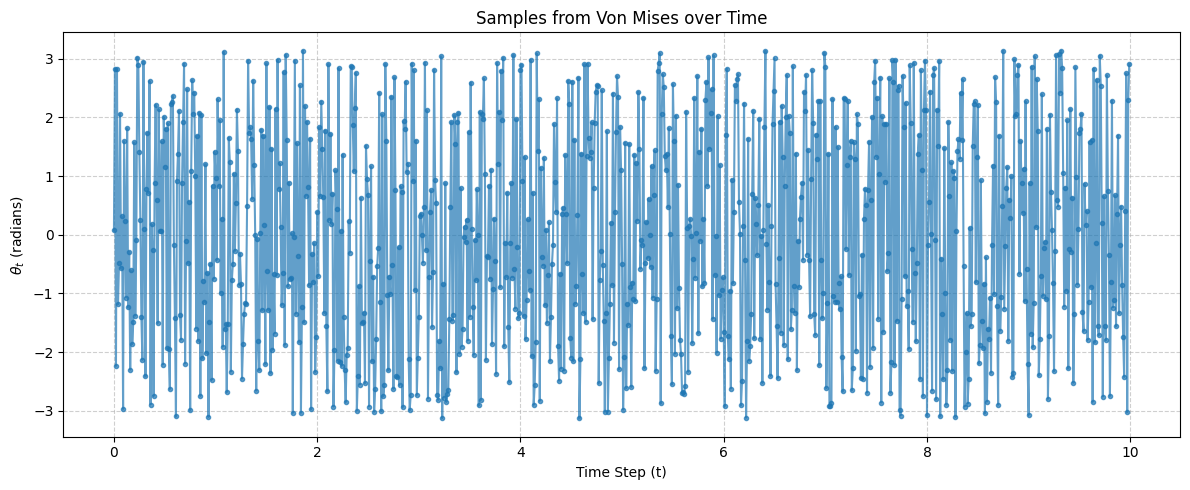

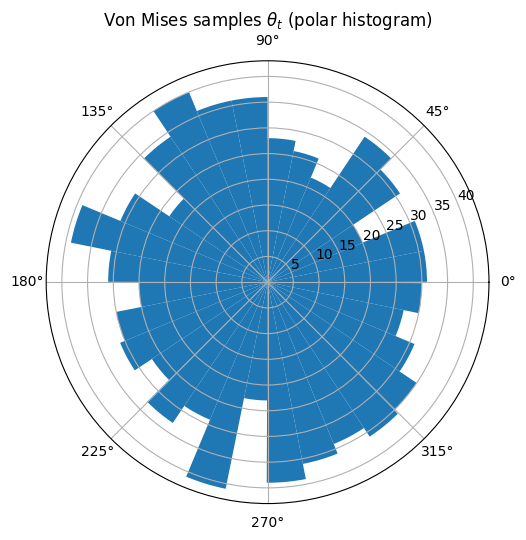

In [4]:
t, theta = simulate_vonmises_tseries(n_steps=T, mu=np.deg2rad(mu_deg), kappa=kappa, dt=dt, seed=theta_seed)

# visualize vonmises

plot_vomises_ts(t, theta)
plot_polar_hist(theta, bins=32)

### Gaussian process to get s(θ)

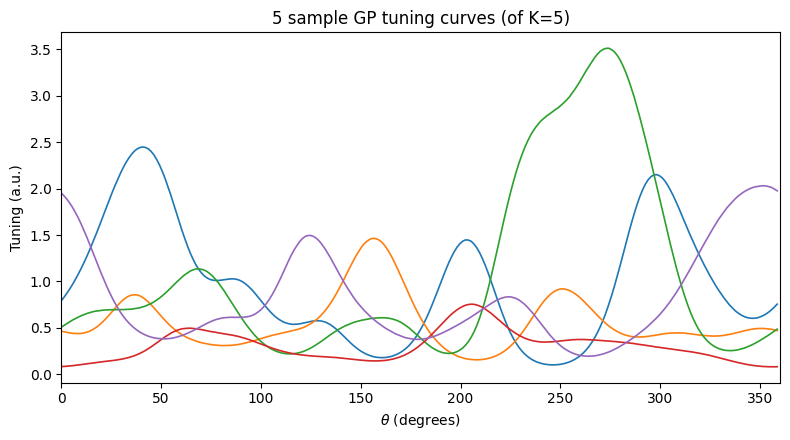

In [5]:
n_bins_array, S = sample_gp_tuning_functions(
        K=K, n_bins=n_bins, length_scale=length_scale, variance=variance,
        mean=mean, transform=transform, seed=gp_seed)

R = evaluate_tuning_at_angles(S, n_bins_array, theta) # (T, k)

plot_tuning_curves(n_bins_array, S, n_show=K)

### Adding OU process to the $s(\theta)$ to create drift

In [6]:
# ---------------------- OU drift for gains A_t ----------------------
def ou_drift(d_steps, N, K, alpha=0.01, seed=None):
    r"""
    Simulate OU drift for K dimensions over d_steps time steps.
    
    U_{t+1} = U_t \sqrt{1-\alpha} + \xi \sqrt{\alpha}
    \xi ~ {N}(0, I)
    
    """
    rng = np.random.default_rng(seed)
    U_0 = rng.standard_normal((N, K))  # initial state
    U = U_0.copy()
    for t in range(d_steps):
        U_t = U * np.sqrt(1 - alpha) + rng.standard_normal((N, K)) * np.sqrt(alpha)
        U = U_t
    return U, U_0 # shape (N, K)


# ---- Visualize OU drift ----

def plot_neurons_lineplot(X, ylabel="Neuron", title= None):
    """Plot neural responses in separate subplots with consistent y-axis.
    
    Args:
        t: time points
        X: array of shape (N, T) where N is number of neurons
        ylabel: y-axis label base
        title: plot title
    """
    n_neurons = X.shape[0]
    colors = plt.cm.tab10(np.linspace(0, 1, n_neurons))  # Get n_neurons distinct colors
    
    # Calculate global y-axis limits for consistency
    y_min = X[:, :n_neurons].min()
    y_max = X[:, :n_neurons].max()
    y_range = y_max - y_min
    y_limits = [y_min - 0.1*y_range, y_max + 0.1*y_range]
    
    # Create subplots with minimal spacing
    fig, axs = plt.subplots(n_neurons, 1, figsize=(9, n_neurons), sharex=True)
    fig.suptitle(title, y=0.95)
    
    # Plot each neuron in its own subplot
    lines = []  # Store lines for legend
    labels = []  # Store labels for legend

    t = np.arange(X.shape[1]) 
    
    for i in range(n_neurons):
        line = axs[i].plot(t, X[i, :], linewidth=1.0, color=colors[i])[0]
        lines.append(line)
        labels.append(f'{ylabel} {i+1}')
        
        axs[i].set_ylim(y_limits)
        # Remove all spines and ticks
        for spine in axs[i].spines.values():
            spine.set_visible(False)
        axs[i].tick_params(left=False, labelleft=False, bottom=False)
        
        # Add minimal y-label
        axs[i].text(-0.02, 0.5, f'{i+1}', transform=axs[i].transAxes,
                    verticalalignment='center', horizontalalignment='right')
    
    # Add single legend for all subplots
    fig.legend(lines, labels, loc='center right', bbox_to_anchor=(1.15, 0.5))
    
    # Set xlabel only on bottom subplot
    axs[-1].set_xlabel("Time (s)")
    
    # Adjust spacing
    plt.subplots_adjust(hspace=0.05, right=0.85)
    plt.show()


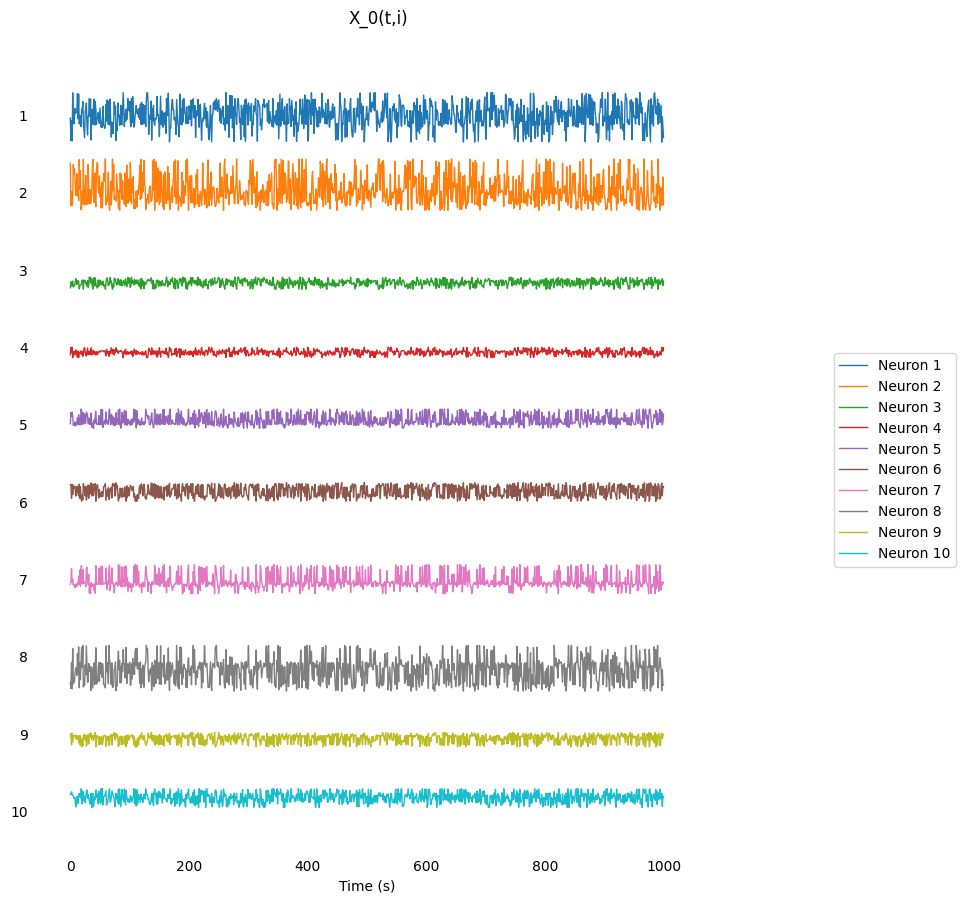

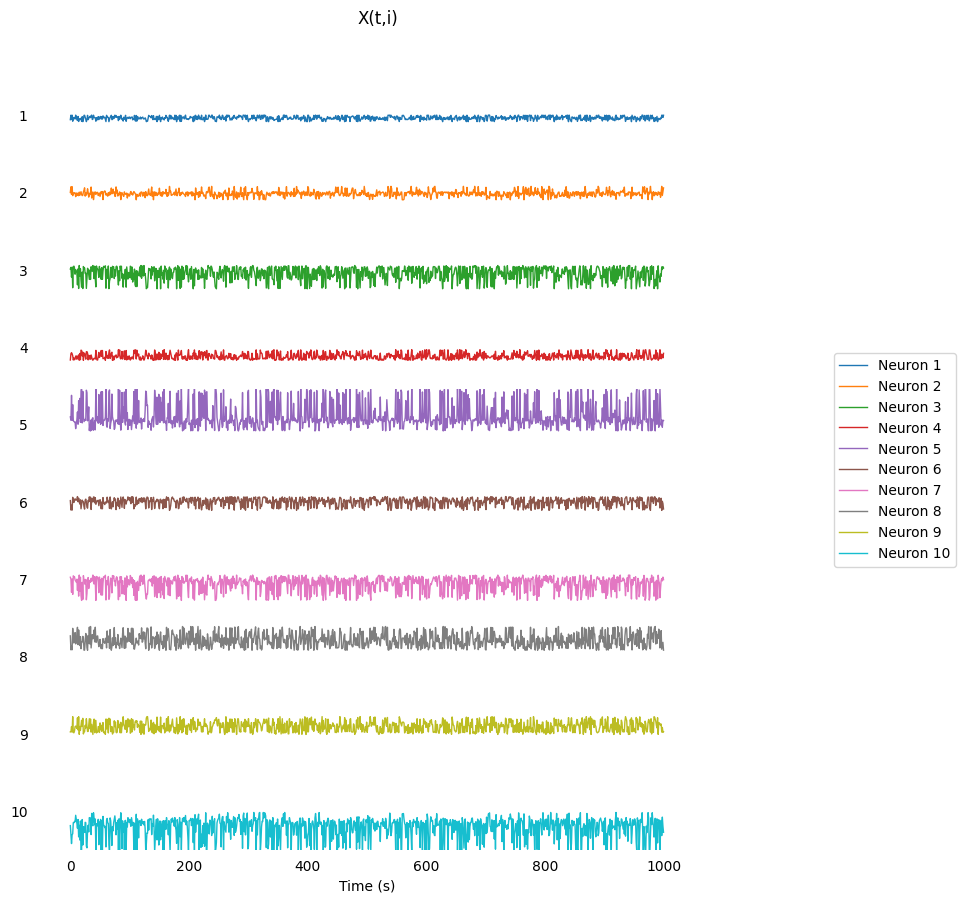

In [7]:
alpha = 0.02
ou_seed = 3
N = 10
d_steps = 1000

U, U_0 = ou_drift(d_steps=d_steps, N=N, K=K, alpha=alpha, seed=ou_seed)

X = U @ R.T  # shape (N, T)
X0 = U_0 @ R.T # initial state
# visualization

plot_neurons_lineplot(X0, title="X_0(t,i)")
plot_neurons_lineplot(X, title = "X(t,i)")


### PCA in the original space & drifted space

In [8]:
# pca_theta_geometry.py
# PCA of R (T x K) and visualization of θ geometry in PC space.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap
from sklearn.decomposition import PCA


# ---------- PCA helpers ----------
def pca_on_X0(X0, n_components=5, center=True, zscore=False):
    """
    X : (N, T) stimulus-drive matrix (rows=neurons, cols=time)
    center : subtract per-neuron mean
    zscore : standardize per neuron (over time). If True, 'center' is implied.
    Returns:
        Z   : (T, n_components) PC scores
        pca : fitted sklearn PCA object (pca.components_, explained_variance_ratio_, ...)
        X0  : centered/scaled data used to fit (for reproducibility)
    """
    _X = np.asarray(X0.T, float)
    mu = _X.mean(axis=0, keepdims=True)
    if zscore:
        sd = _X.std(axis=0, keepdims=True) + 1e-9
        _X0 = (_X - mu) / sd
    elif center:
        _X0 = _X - mu
    else:
        _X0 = _X.copy()

    pca = PCA(n_components=n_components, svd_solver="full")
    Z = pca.fit_transform(_X0)
    return Z, pca

# ---------- Plotters ----------
def plot_pc2(Z, theta, title="PC1 vs PC2 colored by θ", cmap_name="hsv", s=8):
    th = (theta % TAU)
    norm = Normalize(vmin=0.0, vmax=TAU)
    cmap = get_cmap(cmap_name)
    colors = cmap(norm(th))

    fig, ax = plt.subplots(figsize=(6.2, 5.2))
    ax.scatter(Z[:, 0], Z[:, 1], c=colors, s=s, edgecolors="none")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_title(title)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])

    # create colorbar tied to this Axes
    cbar = fig.colorbar(sm, ax=ax, ticks=np.linspace(0, TAU, 9))
    cbar.ax.set_yticklabels([f"{int(d)}°" for d in np.linspace(0, 360, 9)])
    cbar.set_label("θ")
    fig.tight_layout()

def plot_pc3(Z, theta, title="PC1–PC2–PC3 colored by θ", cmap_name="hsv", s=6):
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    th = (theta % TAU)
    norm = Normalize(vmin=0.0, vmax=TAU)
    cmap = get_cmap(cmap_name)
    colors = cmap(norm(th))

    fig = plt.figure(figsize=(7.0, 6.0))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], c=colors, s=s, depthshade=False)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
    ax.set_title(title)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    fig.colorbar(sm, ax=ax, pad=0.1, label="θ")
    fig.tight_layout()

# ---------- Optional: decode θ from top q PCs (sanity check) ----------
def decode_theta_from_pcs(Z, theta, q=2):
    """
    Fit a linear map from Z[:, :q] -> [sin θ, cos θ]; return decoded angles and R^2.
    """
    th = (theta % TAU)
    Y = np.column_stack([np.sin(th), np.cos(th)])  # (T,2)
    X = Z[:, :q]
    W, *_ = np.linalg.lstsq(X, Y, rcond=None)     # (q,2)
    Yhat = X @ W                                   # (T,2)
    th_hat = np.arctan2(Yhat[:, 0], Yhat[:, 1])    # atan2(sin, cos)

    # Compute coefficient of determination separately for sin and cos
    def r2(y, yhat):
        ss_res = np.sum((y - yhat)**2)
        ss_tot = np.sum((y - y.mean())**2) + 1e-12
        return 1 - ss_res/ss_tot
    r2_sin = r2(Y[:, 0], Yhat[:, 0])
    r2_cos = r2(Y[:, 1], Yhat[:, 1])
    return th_hat, (r2_sin, r2_cos)

# ---------- One-call convenience ----------
# if do_decoder:
#     th_hat, (r2_sin, r2_cos) = decode_theta_from_pcs(Z, theta, q=min(2, n_components))
#     err_deg = np.rad2deg(np.angle(np.exp(1j*(theta - th_hat))))  # wrapped error in degrees
#     print(f"Linear decode from top-2 PCs → R²(sin)={r2_sin:.3f}, R²(cos)={r2_cos:.3f}")
#     plt.figure(figsize=(6.2, 3.6))
#     plt.plot(err_deg, linewidth=0.9)
#     plt.xlabel("Time"); plt.ylabel("Angle error (deg)")
#     plt.title("θ decoding error (top-2 PCs → sin/cos)")
#     plt.tight_layout()


Explained variance ratio (first 5 PCs): [0.4247 0.2803 0.1805 0.1119 0.0026]


/tmp/ipykernel_22278/99265772.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)
/tmp/ipykernel_22278/99265772.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)


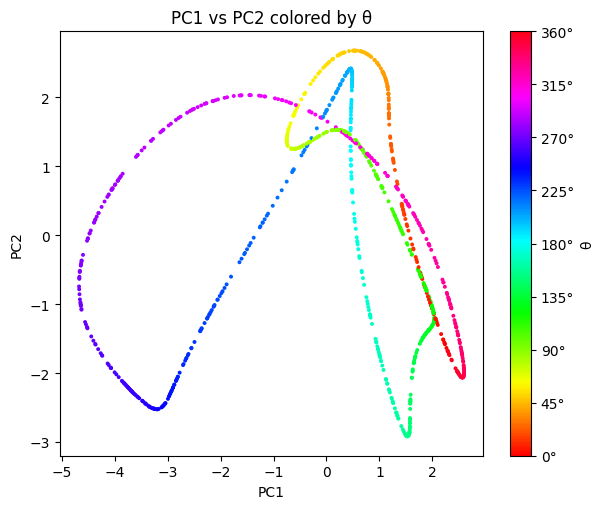

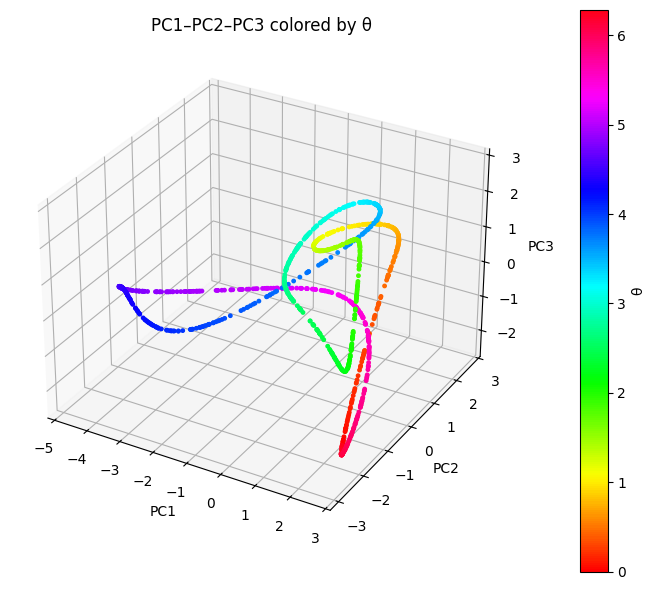

In [9]:
n_components = 5
center = True
zscore = True

Z, pca = pca_on_X0(X0, n_components=n_components, center=center, zscore=zscore)
evr = pca.explained_variance_ratio_
print(f"Explained variance ratio (first {n_components} PCs): {np.round(evr, 4)}")

plot_pc2(Z, theta, title="PC1 vs PC2 colored by θ")
plot_pc3(Z, theta, title="PC1–PC2–PC3 colored by θ")

### After-drift geometry in PC space

In [10]:

# ----------------------------- PCA utils -----------------------------
def fit_pca_on_X0(X0, n_components=5, zscore=True):
    """
    Fit PCA on X0 with a frozen preprocessing pipeline.
    Returns:
      pca: sklearn PCA fitted on preprocessed X0
      prep: dict with {'mu','sd','zscore'} to reapply on any new matrix before transform
      Z_X0: PC scores of X0 (T x n_components)
    """
    X0 = np.asarray(X0.T, float)
    mu = X0.mean(axis=0, keepdims=True)
    if zscore:
        sd = X0.std(axis=0, keepdims=True) + 1e-9
    else:
        sd = np.ones_like(mu)

    _X0 = (X0 - mu) / sd
    pca = PCA(n_components=n_components, svd_solver="full")
    Z_X0 = pca.fit_transform(_X0)
    prep = {"mu": mu, "sd": sd, "zscore": zscore}
    return pca, prep, Z_X0

def project_with_X_pca(X, pca, prep):
    """
    Project X into the PC space defined by X0 (same centering/scaling and PCA).
    """
    _X = (np.asarray(X.T, float) - prep["mu"]) / prep["sd"]
    # Use pca.transform so we also subtract pca.mean_ (≈0 since R0 was centered)
    return pca.transform(_X)   # (T, n_components)

# ----------------------------- Plotters ------------------------------
# --- add/replace these plotters ---

def _theta_colors(theta, cmap_name="hsv"):
    th = (theta % TAU)
    return get_cmap(cmap_name)(Normalize(0.0, TAU)(th))

def plot_pc12_overlay(Z_X0, Z_X, theta_X, title="PC1–PC2: X (colored by θ) + R (black ×)",
                      s_x=10, s_r=22, cmap_name="hsv"):
    colors = _theta_colors(theta_X, cmap_name)
    fig, ax = plt.subplots(figsize=(6.6, 5.4))
    # X: colored points
    ax.scatter(Z_X[:, 0], Z_X[:, 1], c=colors, s=s_x, edgecolors="none", label="X")
    # R: black * markers
    ax.scatter(Z_X0[:, 0], Z_X0[:, 1], c="k", s=s_r, marker="*", linewidths=0.9, alpha=0.95, label="R")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_title(title)

    sm = plt.cm.ScalarMappable(norm=Normalize(0, TAU), cmap=get_cmap(cmap_name))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, ticks=np.linspace(0, TAU, 9), fraction=0.046, pad=0.04)
    cbar.ax.set_yticklabels([f"{int(d)}°" for d in np.linspace(0, 360, 9)])
    cbar.set_label("θ (for X)")

    # Optional legend (R shown as black *)
    ax.legend(loc="best", frameon=False)
    fig.tight_layout()
    return fig, ax

def plot_pc123_overlay(Z_X0, Z_X, theta_X, title="PC1–PC2–PC3: X (colored by θ) + R (black *)",
                       s_x=8, s_r=28, cmap_name="hsv"):
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    colors = _theta_colors(theta_X, cmap_name)
    fig = plt.figure(figsize=(7.2, 6.2))
    ax = fig.add_subplot(111, projection="3d")

    # X: colored points
    ax.scatter(Z_X[:, 0], Z_X[:, 1], Z_X[:, 2], c=colors, s=s_x, depthshade=False, label="X", alpha=0.5)
    # R: black * markers
    ax.scatter(Z_X0[:, 0], Z_X0[:, 1], Z_X0[:, 2], c="k", marker="*",
               s=s_r, depthshade=False, linewidths=0.9, alpha=0.95, label="R")

    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
    ax.set_title(title)

    sm = plt.cm.ScalarMappable(norm=Normalize(0, TAU), cmap=get_cmap(cmap_name))
    sm.set_array([])
    fig.colorbar(sm, ax=ax, pad=0.10, label="θ (for X)")

    # Optional legend
    ax.legend(loc="upper left")
    fig.tight_layout()
    return fig, ax


In [11]:
# %matplotlib widget

/tmp/ipykernel_22278/1222831809.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return get_cmap(cmap_name)(Normalize(0.0, TAU)(th))
/tmp/ipykernel_22278/1222831809.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sm = plt.cm.ScalarMappable(norm=Normalize(0, TAU), cmap=get_cmap(cmap_name))
/tmp/ipykernel_22278/1222831809.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return get_cmap(cmap_name)(Normalize(0.0, TAU)(th))
/tmp/ipykernel_22278/122283180

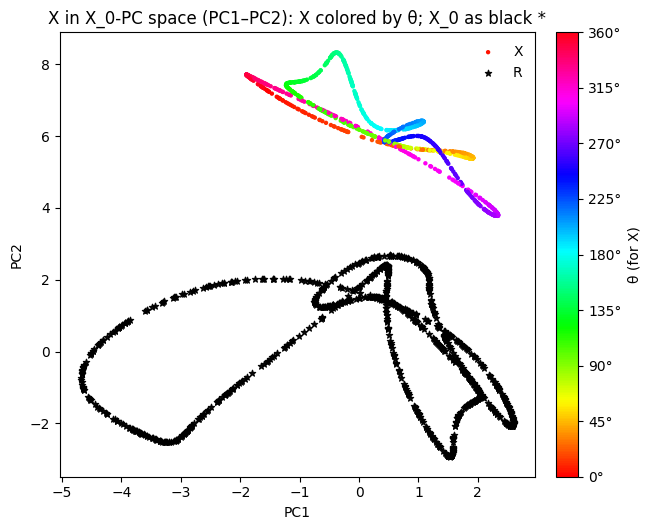

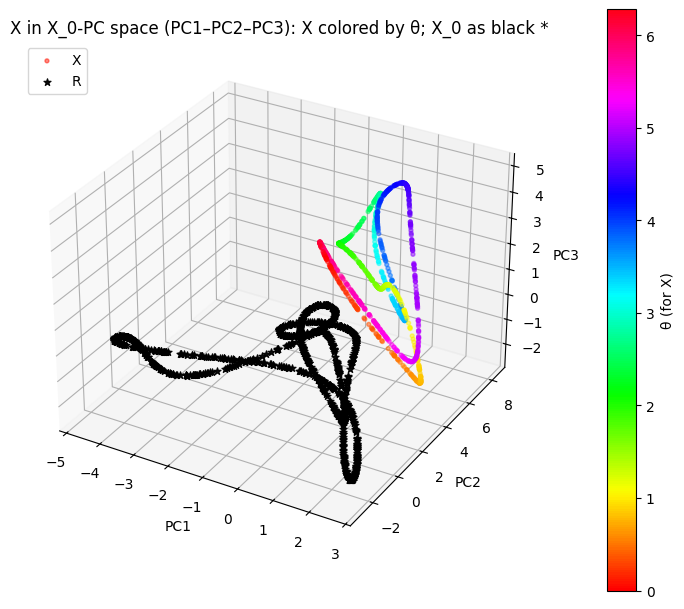

In [12]:
pca, prep, Z_X0 = fit_pca_on_X0(X0, n_components=n_components, zscore=zscore)
Z_X = project_with_X_pca(X, pca, prep)

# --- Visualize X in R's PC space ---
# new (overlay X & R):
plot_pc12_overlay(Z_X0, Z_X, theta,
                title="X in X_0-PC space (PC1–PC2): X colored by θ; X_0 as black *")
plot_pc123_overlay(Z_X0, Z_X, theta,
                    title="X in X_0-PC space (PC1–PC2–PC3): X colored by θ; X_0 as black *")
plt.show()

In [13]:
%matplotlib inline

In [30]:
def covariance_matrix(X):
    """
    Compute covariance matrix: ⟨(X - X̄)^T (X - X̄)⟩
    
    Parameters
    ----------
    X : ndarray, shape (n_features, n_samples)
        Input data matrix.
    
    Returns
    -------
    cov : ndarray, shape (n_features, n_features)
        The covariance matrix.
    """
    X = np.asarray(X)
    # Center the data
    X_centered = X - X.mean(axis=0, keepdims=True)
    # Compute covariance (using N samples)
    cov = (X_centered.T @ X_centered) / (X_centered.shape[0]-1)
    return cov


### Sorting $\theta$ to get the covariance matrix of $s(\theta), X_0(\theta), X(\theta)$

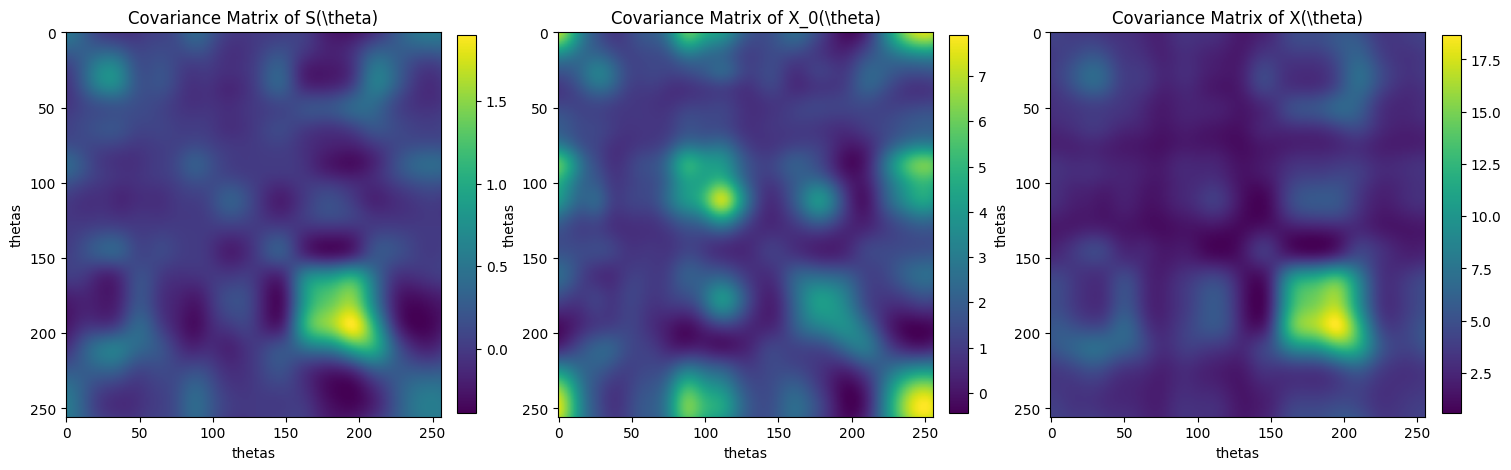

In [31]:
# get theta from [0 to 2pi], with bins = 256
theta_bins = np.linspace(0, 2*np.pi, 256, endpoint=False)
# get different s(\theta) based on the th_bins
S_theta_k = evaluate_tuning_at_angles(S, theta_bins, theta_bins) # (256, K)
# get covariance matrix of S_theta_k
cov_S = covariance_matrix(S_theta_k.T) # (256, 256)

# initial state of the OU process
X0_k = U_0 @ S_theta_k.T
cov_X0_k = covariance_matrix(X0_k)

# After OU drift
X_k = U @ S_theta_k.T
cov_X_k = covariance_matrix(X_k)

# plot three of them, with the cov_S in the center of the first line of the figure, and the cov_X0 and cov_X in the second line of the figure
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
# plot cov_S

cov_list = [cov_S, cov_X0_k, cov_X_k]
titles = [r"Covariance Matrix of S(\theta)",r"Covariance Matrix of X_0(\theta)", r"Covariance Matrix of X(\theta)"]
for i in range(3):
    im = axs[i].imshow(cov_list[i], cmap='viridis', aspect='auto')
    axs[i].set_title(titles[i])
    axs[i].set_xlabel('thetas')
    axs[i].set_ylabel('thetas')
    fig.colorbar(im, ax=axs[i], fraction=0.046, pad=0.04)   
plt.show()
